# HW 2 Fundamentals of Data Visualization Chapters 2 to 5
**Name:** Anees Saheba Guddi  
**SJSU ID:** 018205330  
**GitHub Repo:** [https://github.com/aneessaheba/wilke-dataviz-matplotlib](https://github.com/aneessaheba/wilke-dataviz-matplotlib)

This notebook implements concepts from Chapters 2 to 5 of *Fundamentals of Data Visualization* by Claus O. Wilke using Python Matplotlib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Chapter 2 Visualizing Data: Mapping Data onto Aesthetics

Chapter 2 introduces the concept that every data visualization maps data values to visual aesthetics: position, color, shape, size, line width, and line type. Aesthetics fall into two groups: those that can encode continuous data (position, size, color) and those limited to discrete data (shape, line type). Below we demonstrate multiple aesthetic mappings on the same dataset.

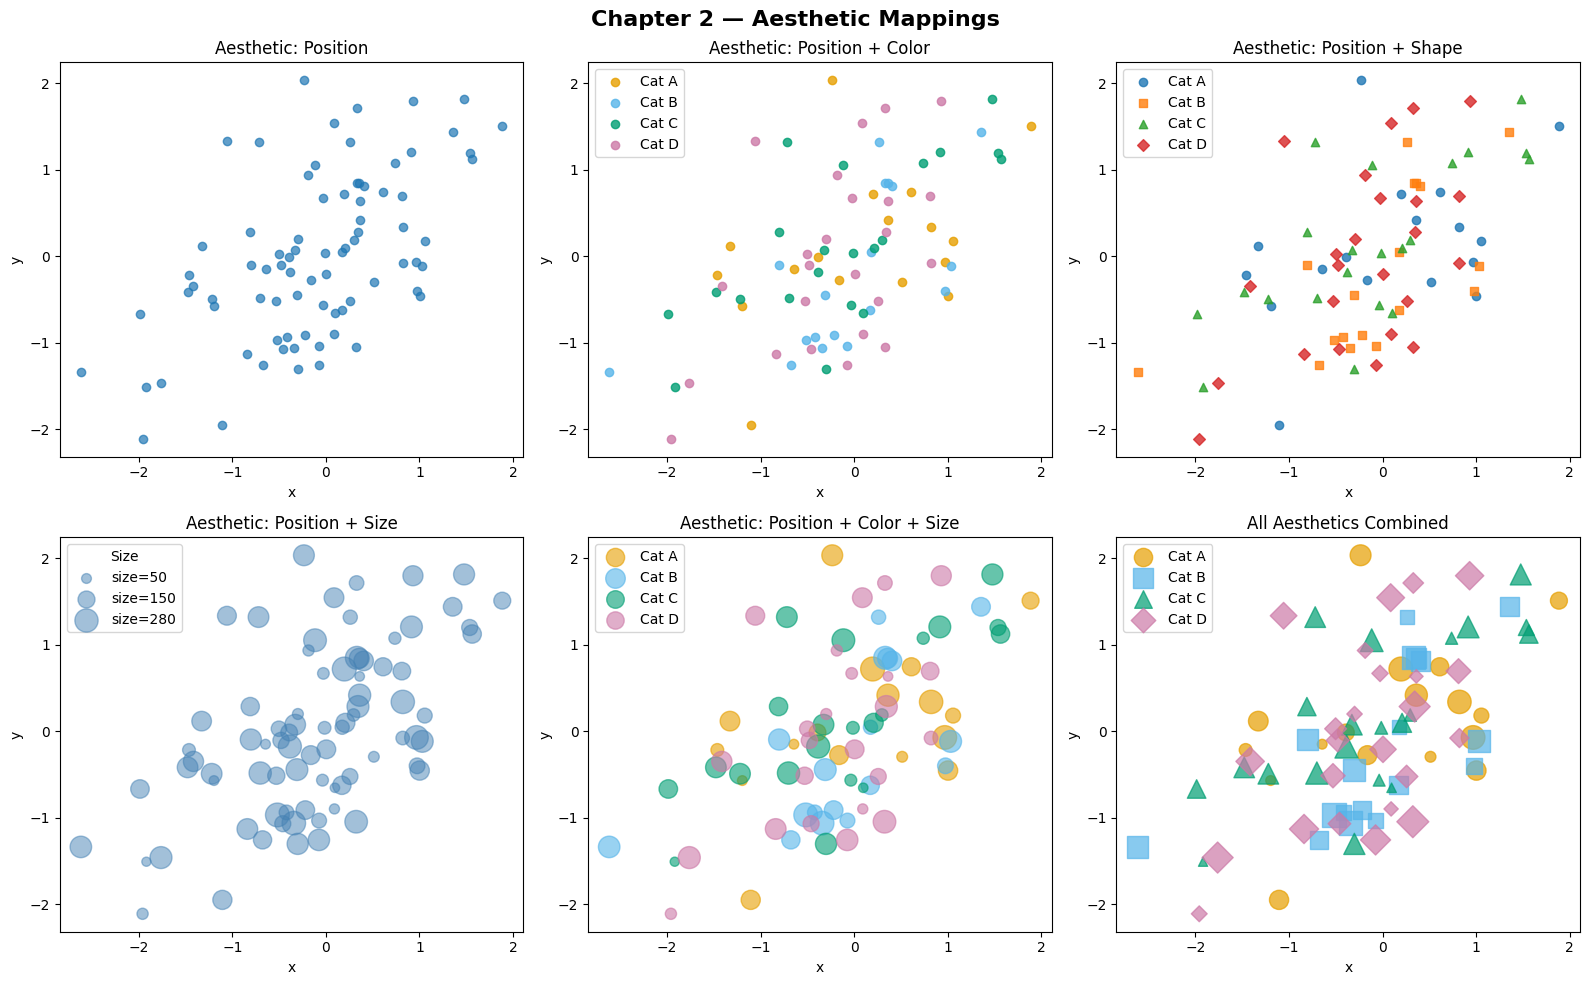

Finding: Each aesthetic mapping adds a new dimension of information. Color and shape distinguish categories effectively, while size encodes a continuous variable.


In [2]:
n = 80
categories = np.random.choice(['A','B','C','D'], n)
x = np.random.randn(n)
y = x * 0.6 + np.random.randn(n) * 0.8
sizes = np.random.uniform(40, 300, n)
df = pd.DataFrame({'x': x, 'y': y, 'cat': categories, 'size': sizes})

color_map = {'A': '#E69F00', 'B': '#56B4E9', 'C': '#009E73', 'D': '#CC79A7'}
shape_map = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Chapter 2 — Aesthetic Mappings', fontsize=16, fontweight='bold')

# 1. Position only
ax = axes[0, 0]
ax.scatter(df['x'], df['y'], alpha=0.7)
ax.set_title('Aesthetic: Position')
ax.set_xlabel('x'); ax.set_ylabel('y')

# 2. Position + Color
ax = axes[0, 1]
for cat, grp in df.groupby('cat'):
    ax.scatter(grp['x'], grp['y'], color=color_map[cat], label=f'Cat {cat}', alpha=0.8)
ax.set_title('Aesthetic: Position + Color')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

# 3. Position + Shape
ax = axes[0, 2]
for cat, grp in df.groupby('cat'):
    ax.scatter(grp['x'], grp['y'], marker=shape_map[cat], label=f'Cat {cat}', alpha=0.8)
ax.set_title('Aesthetic: Position + Shape')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

# 4. Position + Size
ax = axes[1, 0]
sc = ax.scatter(df['x'], df['y'], s=df['size'], alpha=0.5, color='steelblue')
ax.set_title('Aesthetic: Position + Size')
ax.set_xlabel('x'); ax.set_ylabel('y')
for s in [50, 150, 280]:
    ax.scatter([], [], s=s, color='steelblue', alpha=0.5, label=f'size={s}')
ax.legend(title='Size')

# 5. Position + Color + Size
ax = axes[1, 1]
for cat, grp in df.groupby('cat'):
    ax.scatter(grp['x'], grp['y'], s=grp['size'], color=color_map[cat], label=f'Cat {cat}', alpha=0.6)
ax.set_title('Aesthetic: Position + Color + Size')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

# 6. Position + Color + Shape + Size (all aesthetics)
ax = axes[1, 2]
for cat, grp in df.groupby('cat'):
    ax.scatter(grp['x'], grp['y'], s=grp['size'], color=color_map[cat],
               marker=shape_map[cat], label=f'Cat {cat}', alpha=0.7)
ax.set_title('All Aesthetics Combined')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

plt.tight_layout()
plt.savefig('ch2_aesthetics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Each aesthetic mapping adds a new dimension of information. Color and shape distinguish categories effectively, while size encodes a continuous variable.')

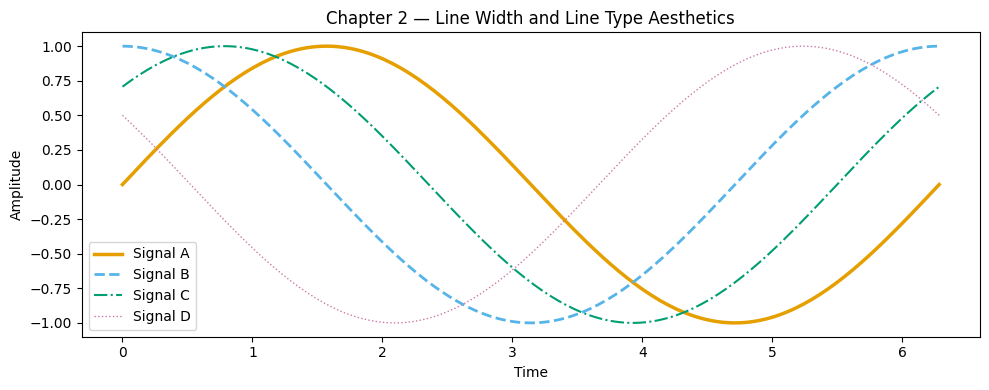

Finding: Line type and width distinguish series without requiring color alone, useful for colorblind-accessible figures.


In [3]:
# Line aesthetics — line width and line type
t = np.linspace(0, 2 * np.pi, 200)
signals = {
    'Signal A': (np.sin(t), '-', 2.5, '#E69F00'),
    'Signal B': (np.cos(t), '--', 2.0, '#56B4E9'),
    'Signal C': (np.sin(t + np.pi/4), '-.', 1.5, '#009E73'),
    'Signal D': (np.cos(t + np.pi/3), ':', 1.0, '#CC79A7'),
}

fig, ax = plt.subplots(figsize=(10, 4))
for label, (y, ls, lw, color) in signals.items():
    ax.plot(t, y, linestyle=ls, linewidth=lw, color=color, label=label)
ax.set_title('Chapter 2 — Line Width and Line Type Aesthetics')
ax.set_xlabel('Time'); ax.set_ylabel('Amplitude')
ax.legend()
plt.tight_layout()
plt.savefig('ch2_line_aesthetics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Line type and width distinguish series without requiring color alone, useful for colorblind-accessible figures.')

## Chapter 3 Coordinate Systems and Axes

Chapter 3 covers Cartesian and non-Cartesian (polar) coordinate systems, axis scaling (linear vs. logarithmic), aspect ratios, and how coordinate transformations reveal different patterns in data.

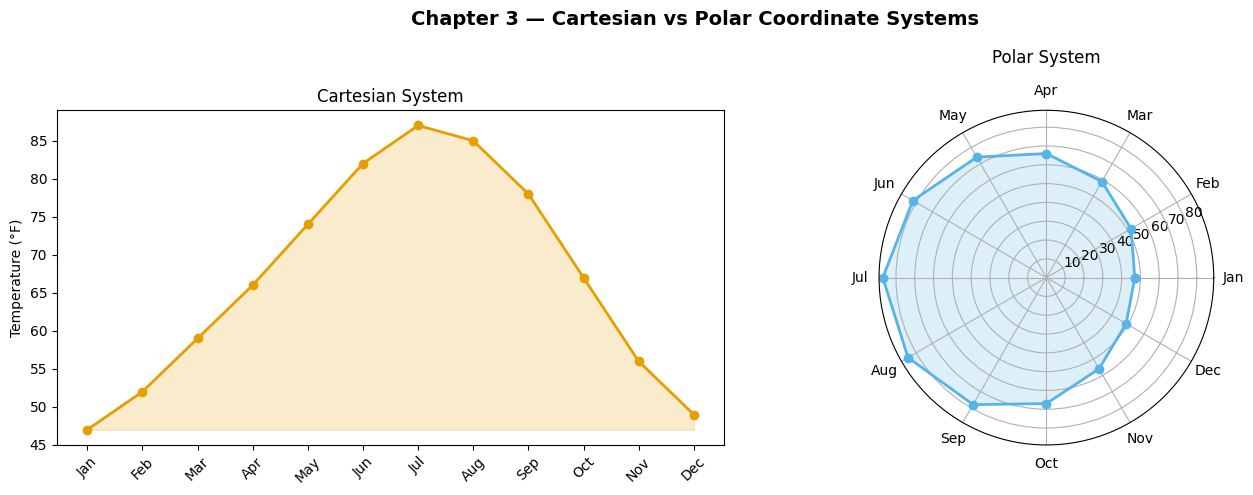

Finding: The polar plot reveals the cyclic nature of seasonal temperature, while Cartesian is better for reading exact values.


In [4]:
# Cartesian vs Polar coordinate systems
months = np.arange(1, 13)
temps = [47, 52, 59, 66, 74, 82, 87, 85, 78, 67, 56, 49]
theta = (months - 1) / 12 * 2 * np.pi

fig = plt.figure(figsize=(14, 5))
fig.suptitle('Chapter 3 — Cartesian vs Polar Coordinate Systems', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(months, temps, 'o-', color='#E69F00', linewidth=2)
ax1.fill_between(months, min(temps), temps, alpha=0.2, color='#E69F00')
ax1.set_xticks(months)
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax1.set_ylabel('Temperature (°F)')
ax1.set_title('Cartesian System')

ax2 = fig.add_subplot(1, 2, 2, projection='polar')
theta_closed = np.append(theta, theta[0])
temps_closed = np.append(temps, temps[0])
ax2.plot(theta_closed, temps_closed, 'o-', color='#56B4E9', linewidth=2)
ax2.fill(theta_closed, temps_closed, alpha=0.2, color='#56B4E9')
ax2.set_xticks(theta)
ax2.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax2.set_title('Polar System', pad=15)

plt.tight_layout()
plt.savefig('ch3_coordinate_systems.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: The polar plot reveals the cyclic nature of seasonal temperature, while Cartesian is better for reading exact values.')

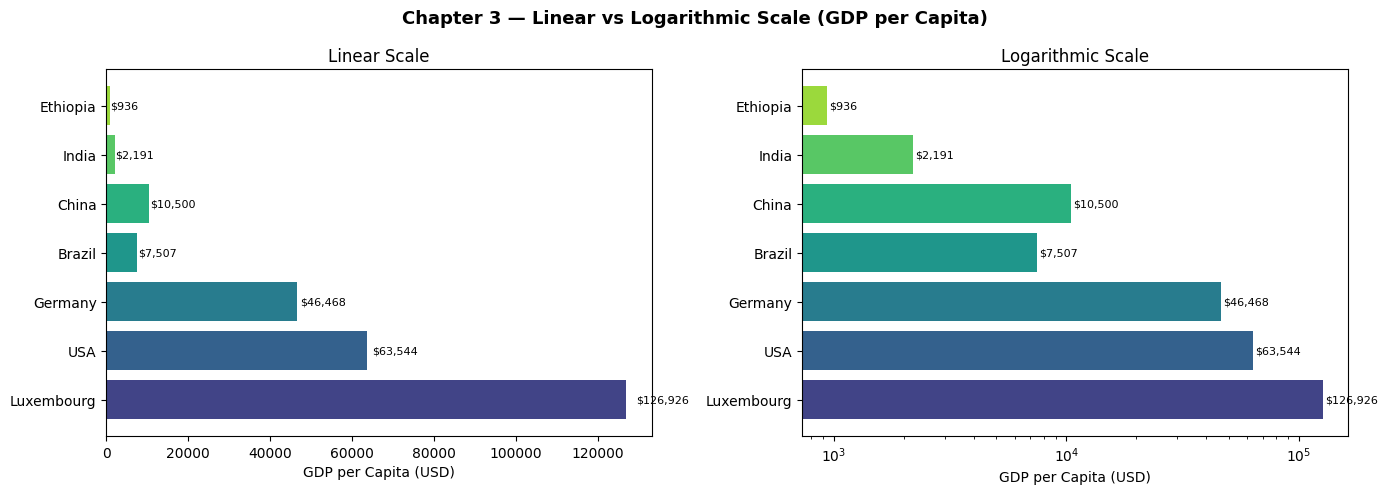

Finding: Linear scale compresses lower-income countries into near-zero bars. Log scale reveals proportional differences across all countries.


In [5]:
# Linear vs Logarithmic axes
countries = ['Luxembourg', 'USA', 'Germany', 'Brazil', 'China', 'India', 'Ethiopia']
gdp_per_capita = [126926, 63544, 46468, 7507, 10500, 2191, 936]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chapter 3 — Linear vs Logarithmic Scale (GDP per Capita)', fontsize=13, fontweight='bold')

colors = cm.viridis(np.linspace(0.2, 0.85, len(countries)))

for ax, scale, title in zip(axes, ['linear', 'log'], ['Linear Scale', 'Logarithmic Scale']):
    bars = ax.barh(countries, gdp_per_capita, color=colors)
    ax.set_xscale(scale)
    ax.set_title(title)
    ax.set_xlabel('GDP per Capita (USD)')
    for bar, val in zip(bars, gdp_per_capita):
        ax.text(val * 1.02, bar.get_y() + bar.get_height()/2,
                f'${val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('ch3_log_vs_linear.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Linear scale compresses lower-income countries into near-zero bars. Log scale reveals proportional differences across all countries.')

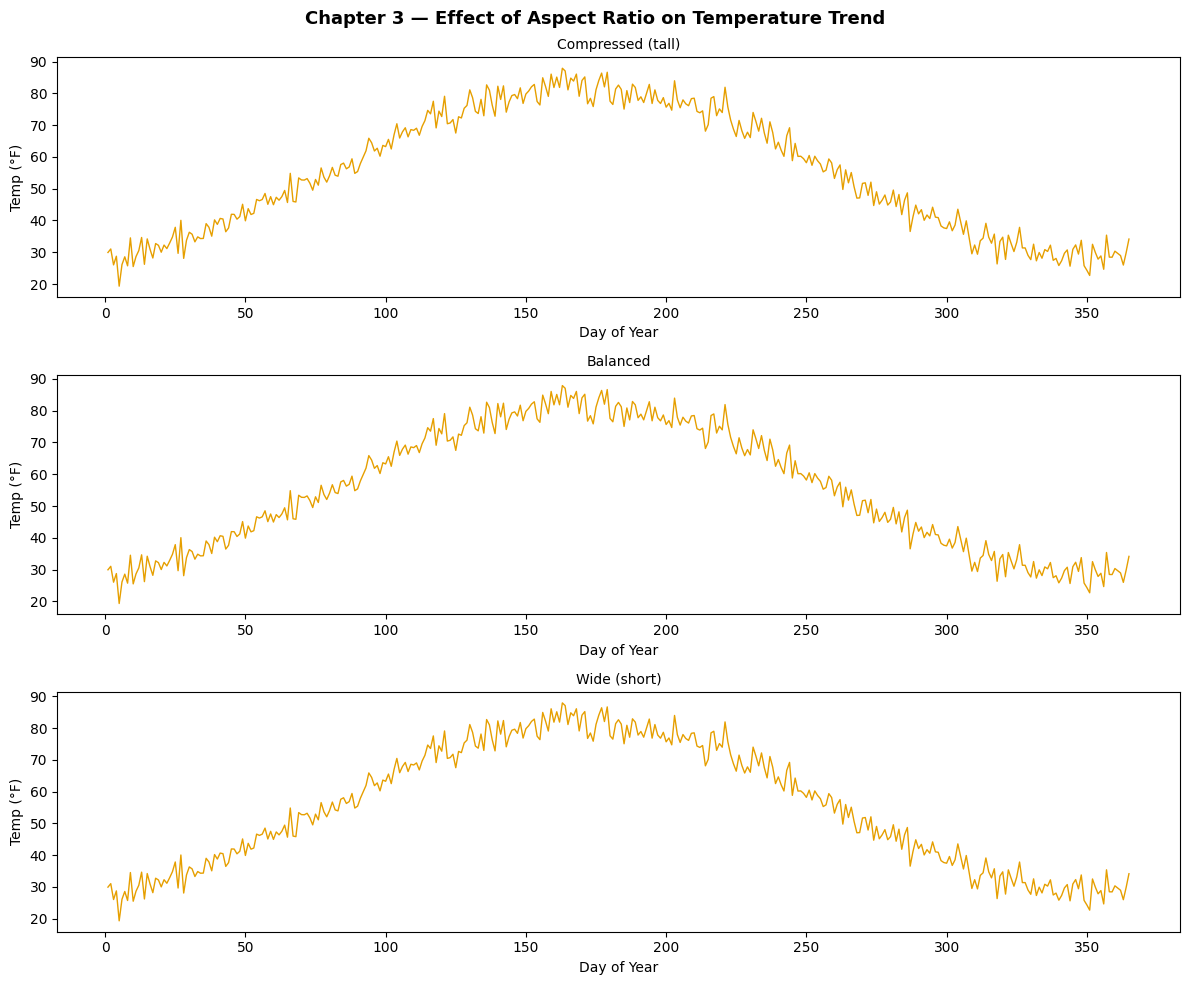

Finding: Aspect ratio changes our perception of slope and variability. A tall plot exaggerates variation; a wide plot downplays it.


In [6]:
# Aspect ratio effect (Ch3 key concept)
days = np.arange(1, 366)
houston_temp = 55 + 27 * np.sin((days - 80) / 365 * 2 * np.pi) + np.random.randn(365) * 3

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Chapter 3 — Effect of Aspect Ratio on Temperature Trend', fontsize=13, fontweight='bold')

titles = ['Compressed (tall)', 'Balanced', 'Wide (short)']
heights = [6, 3, 1.5]

for ax, title in zip(axes, titles):
    ax.plot(days, houston_temp, color='#E69F00', linewidth=1)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Temp (°F)')

plt.tight_layout()
plt.savefig('ch3_aspect_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Aspect ratio changes our perception of slope and variability. A tall plot exaggerates variation; a wide plot downplays it.')

## Chapter 4 Color Scales

Chapter 4 covers three uses of color in visualization: (1) qualitative scales to distinguish categories, (2) sequential scales to represent magnitude, and (3) diverging scales for data with a meaningful midpoint. It also discusses colorblind-safe palettes and when to use color highlighting.

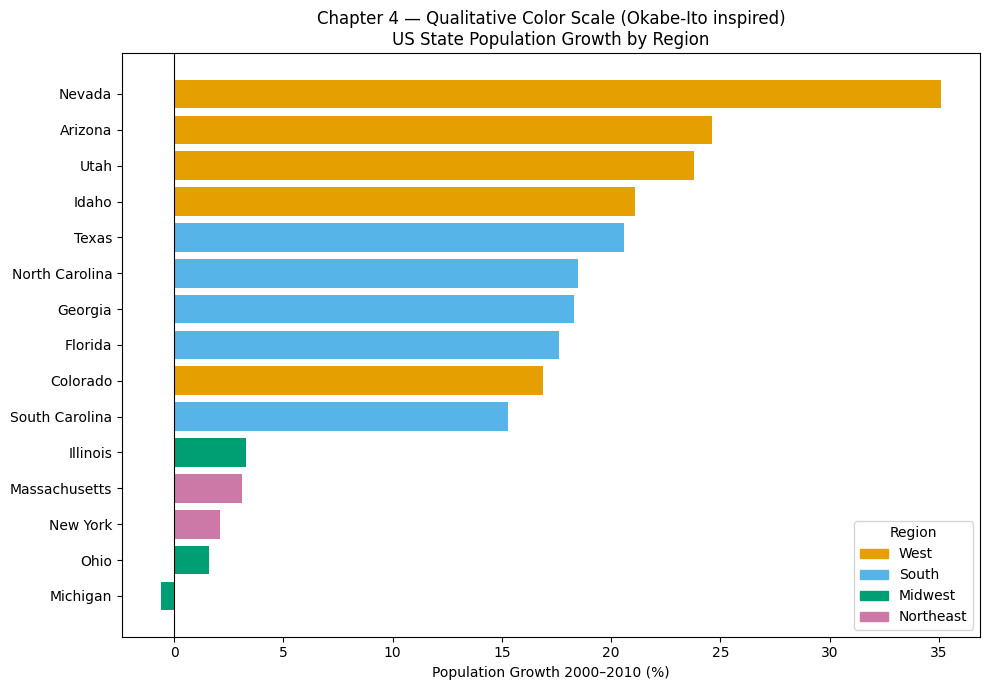

Finding: Qualitative color effectively groups states by region without implying order. Western and Southern states show the highest growth.


In [7]:
# Qualitative color scale — US population growth by region
states = ['Nevada','Arizona','Utah','Idaho','Texas','North Carolina','Florida',
          'Georgia','Colorado','South Carolina','Michigan','Ohio','Illinois',
          'New York','Massachusetts']
growth = [35.1, 24.6, 23.8, 21.1, 20.6, 18.5, 17.6, 18.3, 16.9, 15.3, -0.6, 1.6, 3.3, 2.1, 3.1]
regions = ['West','West','West','West','South','South','South','South','West','South',
           'Midwest','Midwest','Midwest','Northeast','Northeast']

region_colors = {'West': '#E69F00', 'South': '#56B4E9', 'Midwest': '#009E73', 'Northeast': '#CC79A7'}
colors_bar = [region_colors[r] for r in regions]

df_pop = pd.DataFrame({'state': states, 'growth': growth, 'region': regions})
df_pop = df_pop.sort_values('growth')

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(df_pop['state'], df_pop['growth'],
               color=[region_colors[r] for r in df_pop['region']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Population Growth 2000–2010 (%)')
ax.set_title('Chapter 4 — Qualitative Color Scale (Okabe-Ito inspired)\nUS State Population Growth by Region')
patches = [mpatches.Patch(color=v, label=k) for k, v in region_colors.items()]
ax.legend(handles=patches, title='Region')
plt.tight_layout()
plt.savefig('ch4_qualitative_color.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Qualitative color effectively groups states by region without implying order. Western and Southern states show the highest growth.')

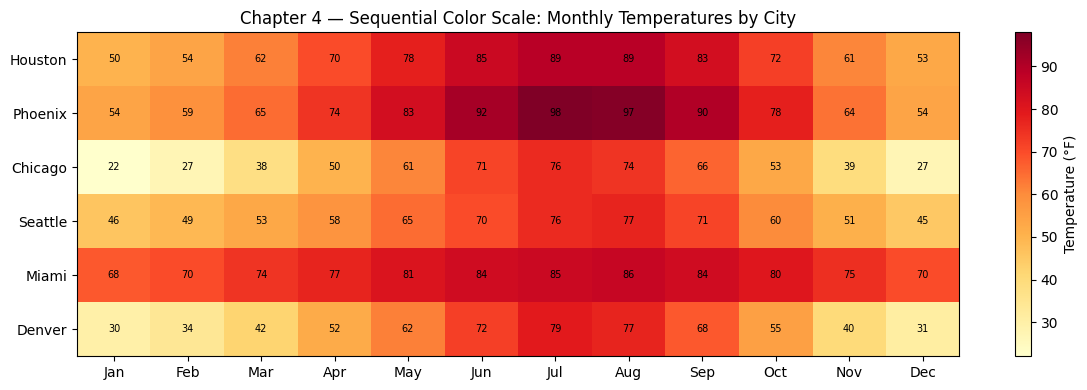

Finding: Sequential color maps magnitude effectively. Phoenix and Miami show the warmest profiles; Chicago and Denver the coldest winters.


In [8]:
# Sequential color scale — temperature heatmap
months_label = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cities = ['Houston','Phoenix','Chicago','Seattle','Miami','Denver']
temps_grid = np.array([
    [50,54,62,70,78,85,89,89,83,72,61,53],
    [54,59,65,74,83,92,98,97,90,78,64,54],
    [22,27,38,50,61,71,76,74,66,53,39,27],
    [46,49,53,58,65,70,76,77,71,60,51,45],
    [68,70,74,77,81,84,85,86,84,80,75,70],
    [30,34,42,52,62,72,79,77,68,55,40,31],
])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(temps_grid, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(12)); ax.set_xticklabels(months_label)
ax.set_yticks(range(len(cities))); ax.set_yticklabels(cities)
plt.colorbar(im, ax=ax, label='Temperature (°F)')
ax.set_title('Chapter 4 — Sequential Color Scale: Monthly Temperatures by City')
for i in range(len(cities)):
    for j in range(12):
        ax.text(j, i, str(temps_grid[i, j]), ha='center', va='center', fontsize=7, color='black')
plt.tight_layout()
plt.savefig('ch4_sequential_color.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Sequential color maps magnitude effectively. Phoenix and Miami show the warmest profiles; Chicago and Denver the coldest winters.')

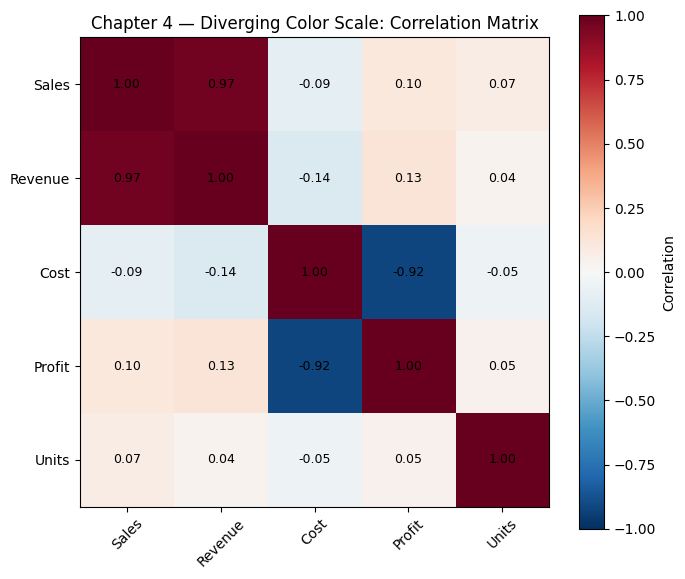

Finding: Diverging palette (Red–White–Blue) centers on zero correlation, making positive and negative relationships immediately apparent.


In [9]:
# Diverging color scale — correlation matrix
np.random.seed(7)
data_raw = np.random.randn(100, 5)
data_raw[:, 1] = data_raw[:, 0] * 0.8 + data_raw[:, 1] * 0.2
data_raw[:, 3] = -data_raw[:, 2] * 0.7 + data_raw[:, 3] * 0.3
df_corr = pd.DataFrame(data_raw, columns=['Sales','Revenue','Cost','Profit','Units'])
corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_xticks(range(5)); ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticks(range(5)); ax.set_yticklabels(corr.columns)
ax.set_title('Chapter 4 — Diverging Color Scale: Correlation Matrix')
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('ch4_diverging_color.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Diverging palette (Red–White–Blue) centers on zero correlation, making positive and negative relationships immediately apparent.')

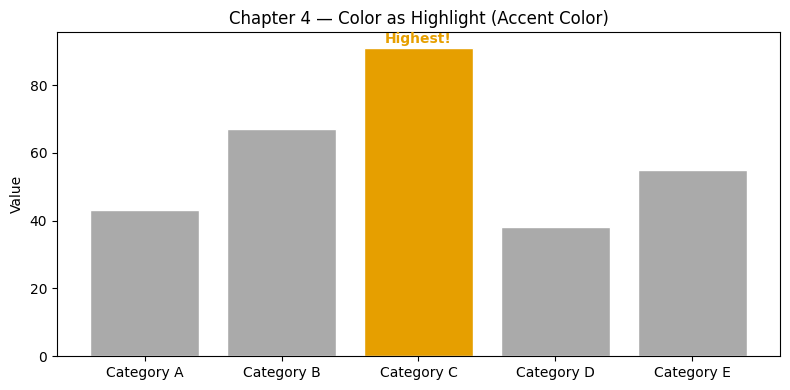

Finding: Using a single accent color against gray draws immediate attention to the key data point without distracting from the overall pattern.


In [10]:
# Color highlighting — accent one group
categories2 = ['Category A','Category B','Category C','Category D','Category E']
values2 = [43, 67, 91, 38, 55]
highlight_idx = 2
bar_colors = ['#AAAAAA' if i != highlight_idx else '#E69F00' for i in range(len(values2))]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(categories2, values2, color=bar_colors, edgecolor='white')
ax.set_title('Chapter 4 — Color as Highlight (Accent Color)')
ax.set_ylabel('Value')
ax.text(highlight_idx, values2[highlight_idx] + 1.5, 'Highest!', ha='center', fontweight='bold', color='#E69F00')
plt.tight_layout()
plt.savefig('ch4_highlight_color.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Using a single accent color against gray draws immediate attention to the key data point without distracting from the overall pattern.')

## Chapter 5 Directory of Visualizations

Chapter 5 surveys the full landscape of visualization types organized by data type: Amounts, Distributions, Proportions, Relationships, and Geospatial. Each visualization type is suited to specific data and questions. Below we implement representative examples from each category.

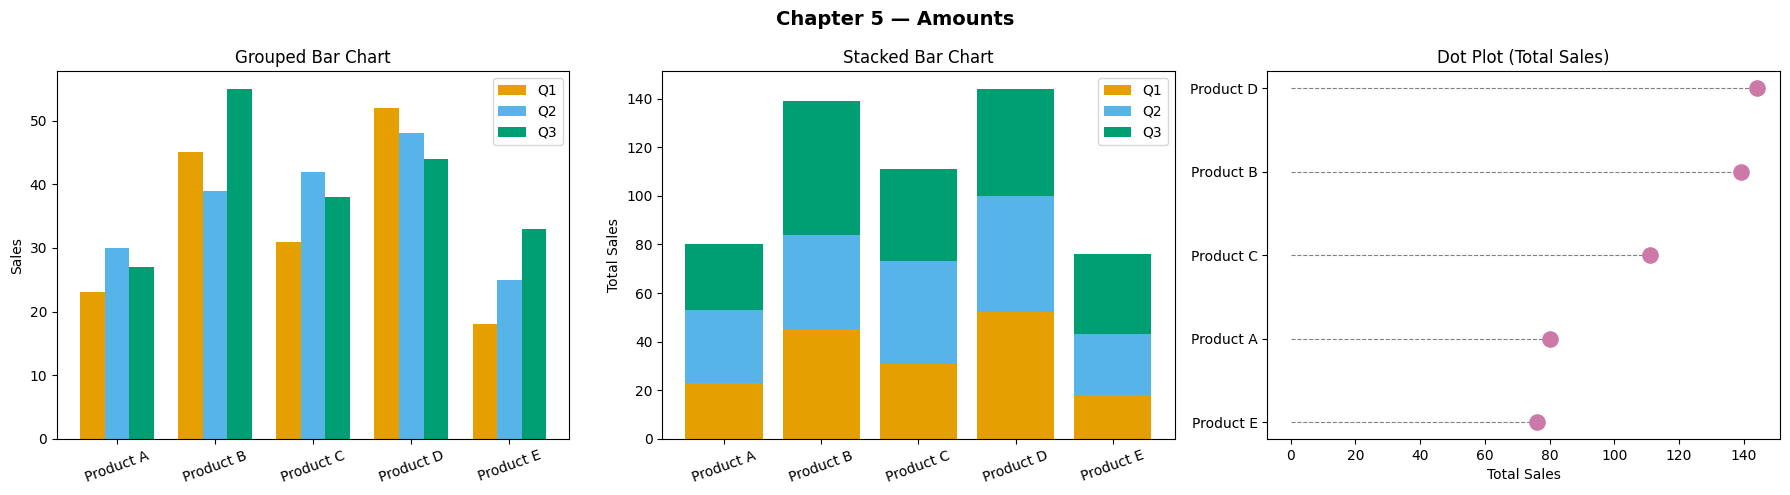

Finding: Grouped bars compare within categories; stacked bars show totals and composition; dot plots are cleaner for ranked comparisons.


In [11]:
# AMOUNTS — bar plots, grouped bars, dot plot, heatmap
products = ['Product A','Product B','Product C','Product D','Product E']
q1 = [23, 45, 31, 52, 18]
q2 = [30, 39, 42, 48, 25]
q3 = [27, 55, 38, 44, 33]

x = np.arange(len(products))
w = 0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Chapter 5 — Amounts', fontsize=14, fontweight='bold')

# Grouped bar
ax = axes[0]
ax.bar(x - w, q1, w, label='Q1', color='#E69F00')
ax.bar(x, q2, w, label='Q2', color='#56B4E9')
ax.bar(x + w, q3, w, label='Q3', color='#009E73')
ax.set_xticks(x); ax.set_xticklabels(products, rotation=20)
ax.set_title('Grouped Bar Chart'); ax.set_ylabel('Sales'); ax.legend()

# Stacked bar
ax = axes[1]
ax.bar(products, q1, label='Q1', color='#E69F00')
ax.bar(products, q2, bottom=q1, label='Q2', color='#56B4E9')
ax.bar(products, q3, bottom=[q1[i]+q2[i] for i in range(5)], label='Q3', color='#009E73')
ax.set_title('Stacked Bar Chart'); ax.set_ylabel('Total Sales')
for label in ax.get_xticklabels(): label.set_rotation(20)
ax.legend()

# Dot plot
total = [q1[i]+q2[i]+q3[i] for i in range(5)]
sorted_idx = np.argsort(total)
ax = axes[2]
ax.scatter([total[i] for i in sorted_idx], range(5), s=120, color='#CC79A7', zorder=3)
for i, idx in enumerate(sorted_idx):
    ax.hlines(i, 0, total[idx], colors='gray', linewidths=0.8, linestyles='--')
ax.set_yticks(range(5)); ax.set_yticklabels([products[i] for i in sorted_idx])
ax.set_title('Dot Plot (Total Sales)'); ax.set_xlabel('Total Sales')

plt.tight_layout()
plt.savefig('ch5_amounts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Grouped bars compare within categories; stacked bars show totals and composition; dot plots are cleaner for ranked comparisons.')

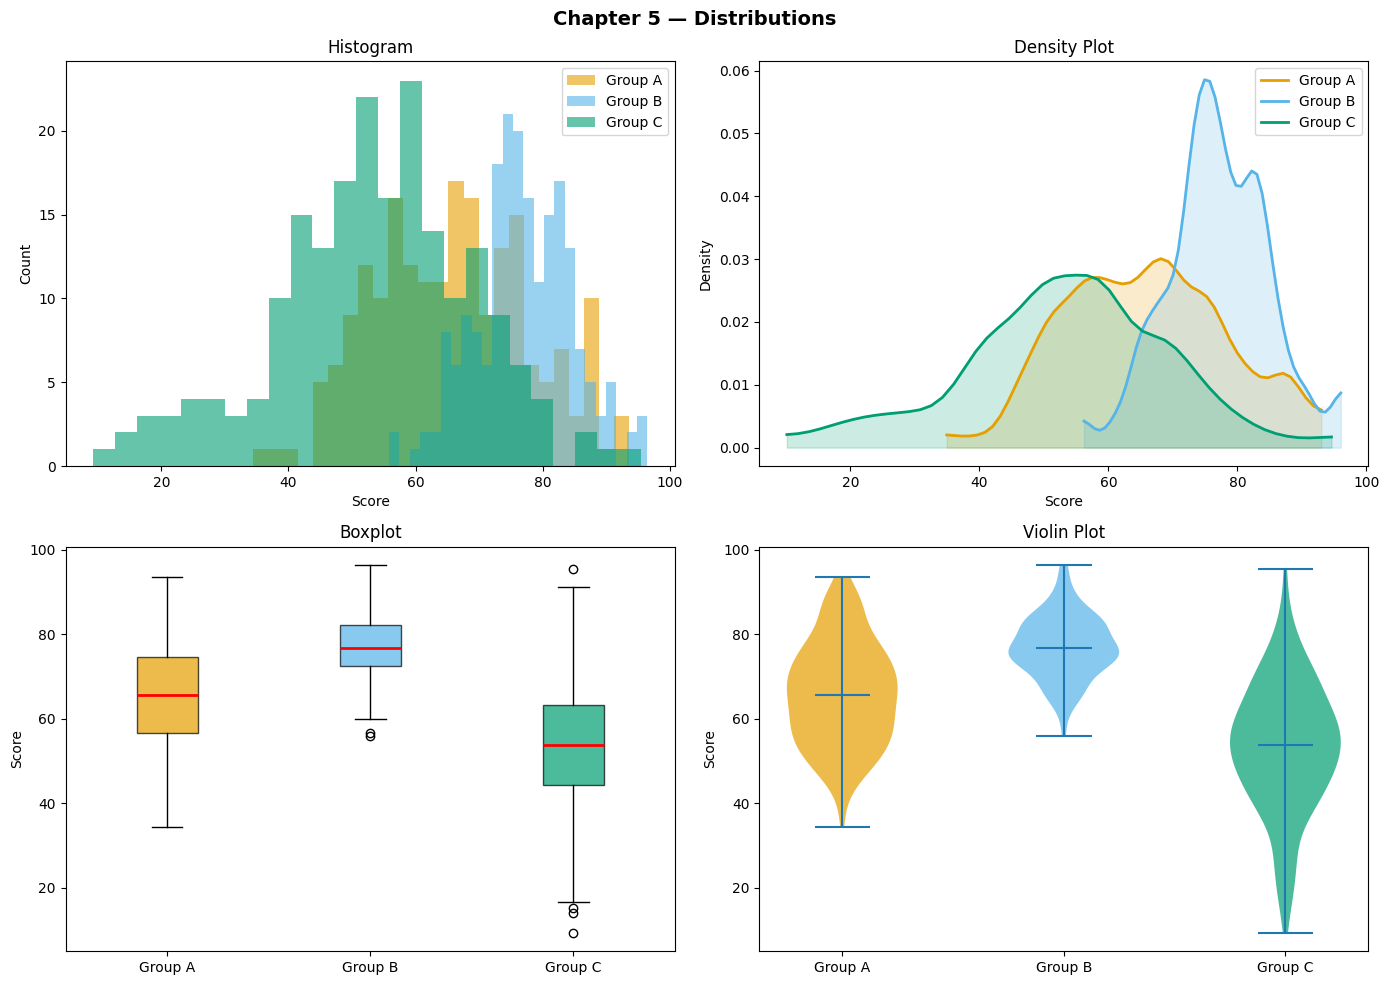

Finding: Group B has the highest and most concentrated scores. Violin plots reveal the full shape; boxplots show outliers efficiently.


In [12]:
# DISTRIBUTIONS — histogram, density, boxplot, violin
np.random.seed(0)
group_a = np.random.normal(65, 12, 200)
group_b = np.random.normal(78, 8, 200)
group_c = np.random.normal(55, 15, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chapter 5 — Distributions', fontsize=14, fontweight='bold')

# Histogram
ax = axes[0, 0]
ax.hist(group_a, bins=25, alpha=0.6, color='#E69F00', label='Group A')
ax.hist(group_b, bins=25, alpha=0.6, color='#56B4E9', label='Group B')
ax.hist(group_c, bins=25, alpha=0.6, color='#009E73', label='Group C')
ax.set_title('Histogram'); ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.legend()

# Density (KDE via numpy)
ax = axes[0, 1]
for grp, color, label in zip([group_a, group_b, group_c],
                               ['#E69F00', '#56B4E9', '#009E73'],
                               ['Group A', 'Group B', 'Group C']):
    counts, bins = np.histogram(grp, bins=50, density=True)
    centers = (bins[:-1] + bins[1:]) / 2
    from scipy.ndimage import gaussian_filter1d
    smooth = gaussian_filter1d(counts, sigma=2)
    ax.plot(centers, smooth, color=color, label=label, linewidth=2)
    ax.fill_between(centers, smooth, alpha=0.2, color=color)
ax.set_title('Density Plot'); ax.set_xlabel('Score'); ax.set_ylabel('Density'); ax.legend()

# Boxplot
ax = axes[1, 0]
bp = ax.boxplot([group_a, group_b, group_c], patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], ['#E69F00', '#56B4E9', '#009E73']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(['Group A', 'Group B', 'Group C'])
ax.set_title('Boxplot'); ax.set_ylabel('Score')

# Violin plot
ax = axes[1, 1]
vp = ax.violinplot([group_a, group_b, group_c], positions=[1, 2, 3], showmedians=True)
for body, color in zip(vp['bodies'], ['#E69F00', '#56B4E9', '#009E73']):
    body.set_facecolor(color); body.set_alpha(0.7)
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(['Group A', 'Group B', 'Group C'])
ax.set_title('Violin Plot'); ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('ch5_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Group B has the highest and most concentrated scores. Violin plots reveal the full shape; boxplots show outliers efficiently.')

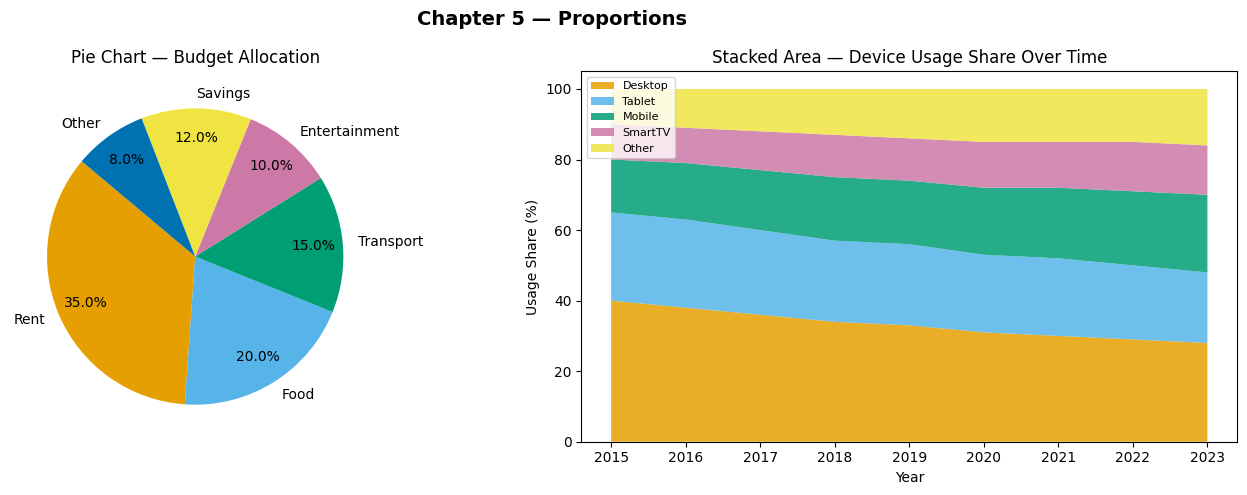

Finding: Pie charts work for part-to-whole at a single moment; stacked area shows how proportions shift over time.


In [13]:
# PROPORTIONS — pie chart, waffle-style bars, stacked area
labels = ['Rent', 'Food', 'Transport', 'Entertainment', 'Savings', 'Other']
sizes = [35, 20, 15, 10, 12, 8]
colors_p = ['#E69F00','#56B4E9','#009E73','#CC79A7','#F0E442','#0072B2']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chapter 5 — Proportions', fontsize=14, fontweight='bold')

# Pie chart
axes[0].pie(sizes, labels=labels, colors=colors_p, autopct='%1.1f%%',
            startangle=140, pctdistance=0.8)
axes[0].set_title('Pie Chart — Budget Allocation')

# Stacked area over time (proportions)
t2 = np.arange(2015, 2024)
share = np.array([
    [40, 38, 36, 34, 33, 31, 30, 29, 28],
    [25, 25, 24, 23, 23, 22, 22, 21, 20],
    [15, 16, 17, 18, 18, 19, 20, 21, 22],
    [10, 10, 11, 12, 12, 13, 13, 14, 14],
    [10, 11, 12, 13, 14, 15, 15, 15, 16],
])
labels2 = ['Desktop','Tablet','Mobile','SmartTV','Other']
axes[1].stackplot(t2, share, labels=labels2, colors=colors_p[:5], alpha=0.85)
axes[1].set_title('Stacked Area — Device Usage Share Over Time')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Usage Share (%)')
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('ch5_proportions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Pie charts work for part-to-whole at a single moment; stacked area shows how proportions shift over time.')

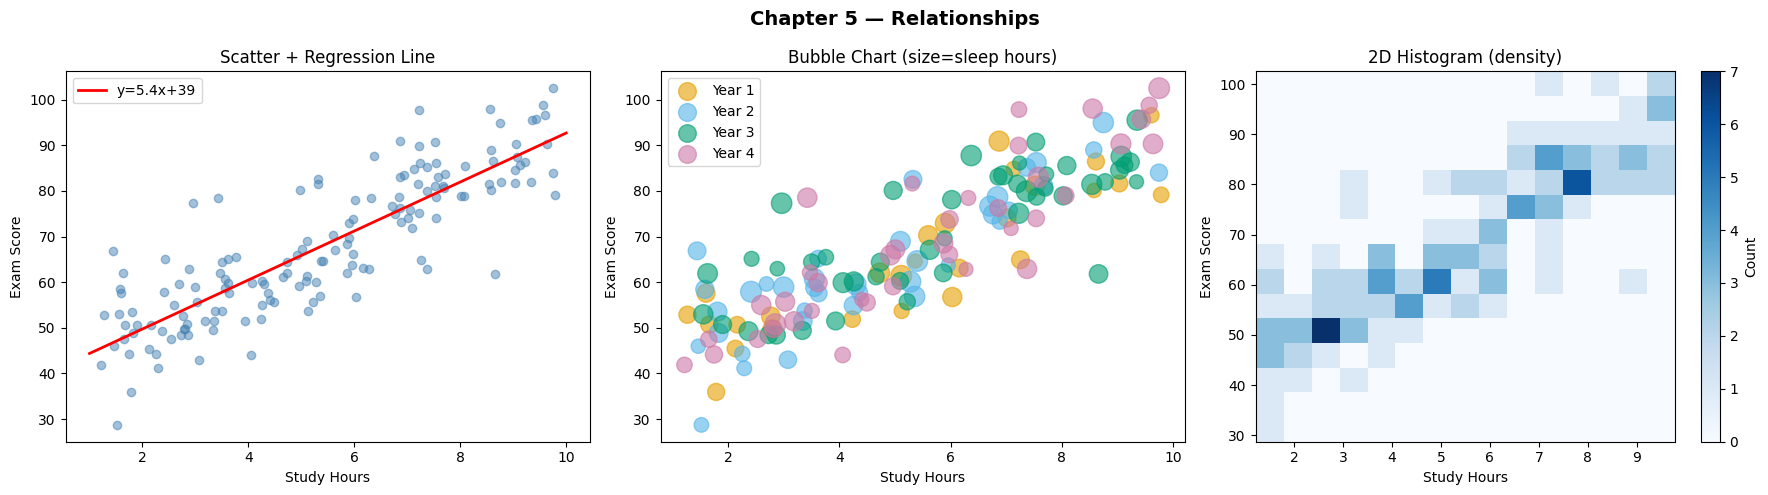

Finding: More study hours strongly correlates with higher exam scores. The bubble chart adds sleep as a 3rd dimension; 2D histogram reveals density structure.


In [14]:
# RELATIONSHIPS — scatter, bubble, 2D histogram
np.random.seed(3)
n2 = 150
study_hours = np.random.uniform(1, 10, n2)
exam_score = 40 + 5 * study_hours + np.random.randn(n2) * 8
sleep_hours = np.random.uniform(4, 9, n2)
year = np.random.choice([1, 2, 3, 4], n2)

year_colors = {1: '#E69F00', 2: '#56B4E9', 3: '#009E73', 4: '#CC79A7'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Chapter 5 — Relationships', fontsize=14, fontweight='bold')

# Scatter with regression line
ax = axes[0]
ax.scatter(study_hours, exam_score, alpha=0.5, color='steelblue')
m, b = np.polyfit(study_hours, exam_score, 1)
x_line = np.linspace(1, 10, 100)
ax.plot(x_line, m * x_line + b, 'r-', linewidth=2, label=f'y={m:.1f}x+{b:.0f}')
ax.set_title('Scatter + Regression Line')
ax.set_xlabel('Study Hours'); ax.set_ylabel('Exam Score'); ax.legend()

# Bubble chart (3 variables)
ax = axes[1]
for yr in [1, 2, 3, 4]:
    mask = year == yr
    ax.scatter(study_hours[mask], exam_score[mask],
               s=sleep_hours[mask] * 25, color=year_colors[yr],
               alpha=0.6, label=f'Year {yr}')
ax.set_title('Bubble Chart (size=sleep hours)')
ax.set_xlabel('Study Hours'); ax.set_ylabel('Exam Score'); ax.legend()

# 2D histogram
ax = axes[2]
h = ax.hist2d(study_hours, exam_score, bins=15, cmap='Blues')
plt.colorbar(h[3], ax=ax, label='Count')
ax.set_title('2D Histogram (density)')
ax.set_xlabel('Study Hours'); ax.set_ylabel('Exam Score')

plt.tight_layout()
plt.savefig('ch5_relationships.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: More study hours strongly correlates with higher exam scores. The bubble chart adds sleep as a 3rd dimension; 2D histogram reveals density structure.')

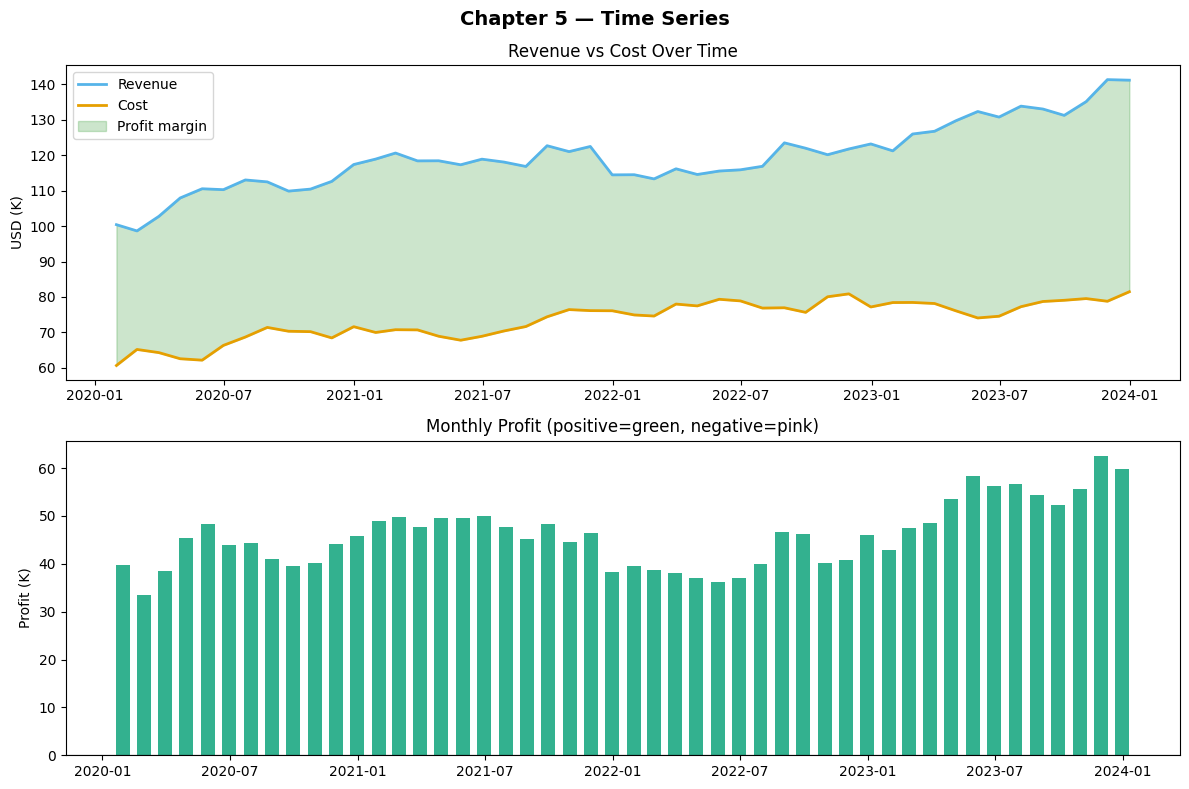

Finding: The area fill between revenue and cost makes the profit margin visually intuitive. Color-coded bars immediately flag any loss months.


In [15]:
# TIME SERIES — line plot + area
dates = pd.date_range('2020-01', periods=48, freq='ME')
revenue = 100 + np.cumsum(np.random.randn(48) * 3) + np.linspace(0, 40, 48)
cost = 60 + np.cumsum(np.random.randn(48) * 2) + np.linspace(0, 20, 48)
profit = revenue - cost

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Chapter 5 — Time Series', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(dates, revenue, label='Revenue', color='#56B4E9', linewidth=2)
ax.plot(dates, cost, label='Cost', color='#E69F00', linewidth=2)
ax.fill_between(dates, cost, revenue, alpha=0.2, color='green', label='Profit margin')
ax.set_title('Revenue vs Cost Over Time'); ax.set_ylabel('USD (K)'); ax.legend()

ax = axes[1]
ax.bar(dates, profit, width=20,
       color=['#009E73' if p >= 0 else '#CC79A7' for p in profit], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Profit (positive=green, negative=pink)')
ax.set_ylabel('Profit (K)')

plt.tight_layout()
plt.savefig('ch5_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: The area fill between revenue and cost makes the profit margin visually intuitive. Color-coded bars immediately flag any loss months.')

## Summary of Findings

| Chapter | Key Concept | Visualization Used | Finding |
|---|---|---|---|
| Ch 2 | Aesthetic Mappings | Scatterplot grid, line plots | Each aesthetic (color, shape, size) adds a dimension of information |
| Ch 3 | Coordinate Systems and Scale | Cartesian vs Polar, Log scale, Aspect ratio | Coordinate choice shapes perception; log scale reveals proportional differences |
| Ch 4 | Color Scales | Qualitative bars, Sequential heatmap, Diverging matrix, Highlight | Each color use case requires a different palette type |
| Ch 5 | Directory of Visualizations | Grouped and stacked bars, distributions, proportions, relationships, time series | Matching chart type to data type is critical for accurate communication |